In [4]:
import pandas as pd
import numpy as np
import re
import string
import nltk

In [5]:
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words("english"))

df = pd.read_csv("twitter_data.csv")
print(df.head())

df['labels'] = df['class'].map({
    0: "Hate Speech detected",
    1: "Offensive language detected",
    2: "No hate and offensive speech"
})

df = df[['tweet', 'labels']]


   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  


In [6]:
def clean(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)                        # remove text in []
    text = re.sub(r'https?://\S+|www\.\S+', '', text)         # remove URLs
    text = re.sub(r'<.*?>', '', text)                          # remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # punctuation
    text = re.sub(r'\n', '', text)                             # newlines
    text = re.sub(r'\w*\d\w*', '', text)                       # words with numbers
    text = [word for word in text.split() if word not in stopword]    # stopwords
    text = [stemmer.stem(word) for word in text]               # stemming
    return " ".join(text)

df['tweet'] = df['tweet'].apply(clean)
print(df.head())


                                               tweet  \
0  rt mayasolov woman shouldnt complain clean hou...   
1   rt boy dat coldtyga dwn bad cuffin dat hoe place   
2  rt urkindofbrand dawg rt ever fuck bitch start...   
3             rt cganderson vivabas look like tranni   
4  rt shenikarobert shit hear might true might fa...   

                         labels  
0  No hate and offensive speech  
1   Offensive language detected  
2   Offensive language detected  
3   Offensive language detected  
4   Offensive language detected  


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

X_text = df['tweet']
y = df['labels']

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [8]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [9]:
y_pred = model.predict(X_test)

print("\n── Model Accuracy ──────────────────────────────")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n── Classification Report ───────────────────────")
print(classification_report(y_test, y_pred))


── Model Accuracy ──────────────────────────────
Accuracy : 79.50%

── Classification Report ───────────────────────
                              precision    recall  f1-score   support

        Hate Speech detected       0.00      0.00      0.00       465
No hate and offensive speech       0.95      0.13      0.22      1379
 Offensive language detected       0.79      1.00      0.88      6335

                    accuracy                           0.79      8179
                   macro avg       0.58      0.38      0.37      8179
                weighted avg       0.77      0.79      0.72      8179



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Confusion matrix saved to confusion_matrix.png


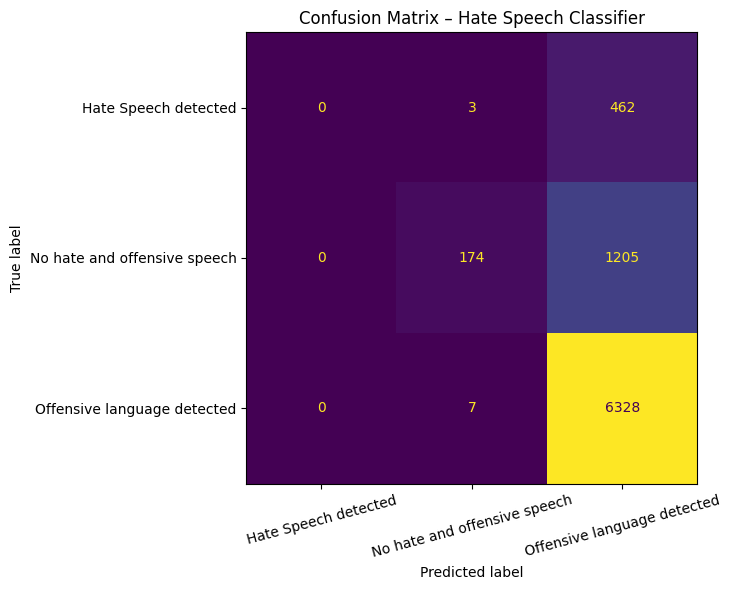

In [10]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=15, colorbar=False)
ax.set_title("Confusion Matrix – Hate Speech Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
print("\nConfusion matrix saved to confusion_matrix.png")
plt.show()

In [11]:
def predict(text: str) -> str:
    cleaned = clean(text)
    vector  = tfidf.transform([cleaned])      # sparse matrix – no .toarray() needed
    return model.predict(vector)[0]

In [13]:
# Demo predictions
samples = [
    "you are awesome",
    "I hate you so much",
    "This is offensive garbage",
]
print("\n── Demo Predictions ────────────────────────────")
for s in samples:
    print(f"  '{s}'  →  {predict(s)}")


── Demo Predictions ────────────────────────────
  'you are nice'  →  Offensive language detected
  'I hate you so much'  →  Offensive language detected
  'This is offensive garbage'  →  Offensive language detected
